# SPY 最新波动率微笑

从 Cboe 公开延迟行情读取 SPY 期权链，展示指定到期日的执行价（strike）与隐含波动率（IV）。每次运行会刷新数据；请求失败时自动使用本地缓存。

> 数据为延迟行情，只适合研究和观察，不应直接用于交易决策。深度实值期权、零买价和不活跃合约的 IV 往往不可靠，因此图中默认只保留现价上下 15%、双边报价有效且有持仓量的合约。

In [1]:
from __future__ import annotations

import json
import re
from datetime import datetime
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

## 参数

修改 `EXPIRATION_INDEX` 可切换到期日：`0` 是最近的尚未到期合约，`1` 是下一个。也可以把 `EXPIRATION` 写成 `YYYY-MM-DD`，精确选择某一天。

In [2]:
SYMBOL = "SPY"
EXPIRATION = None          # 例如 "2026-07-17"；None 时使用下面的序号
EXPIRATION_INDEX = 0       # 0=最近到期，1=次近到期……
MONEYNESS_WINDOW = 0.15    # 仅显示现价上下 15%
MIN_OPEN_INTEREST = 1      # 排除完全不活跃的合约
REQUIRE_TWO_SIDED_QUOTE = True


In [3]:
URL = f"https://cdn.cboe.com/api/global/delayed_quotes/options/{SYMBOL}.json"
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
CACHE_PATH = PROJECT_ROOT / "data/cache" / f"cboe_{SYMBOL.lower()}_options.json"

def load_chain() -> tuple[dict, str]:
    request = Request(URL, headers={"User-Agent": "Mozilla/5.0 volatility-research-notebook"})
    try:
        with urlopen(request, timeout=30) as response:
            payload = json.load(response)
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        CACHE_PATH.write_text(json.dumps(payload), encoding="utf-8")
        return payload, "Cboe live request (delayed quote)"
    except Exception as exc:
        if not CACHE_PATH.exists():
            raise RuntimeError(f"Cboe 请求失败且没有缓存：{exc}") from exc
        return json.loads(CACHE_PATH.read_text(encoding="utf-8")), f"local cache; request failed: {exc}"

payload, data_source = load_chain()
quote = payload["data"]
spot = float(quote["current_price"])
print(f"数据时间: {payload['timestamp']} | SPY: ${spot:,.2f} | 来源: {data_source}")

数据时间: 2026-07-16 12:54:50 | SPY: $751.47 | 来源: Cboe live request (delayed quote)


In [4]:
OCC_PATTERN = re.compile(r"^(?P<root>[A-Z]+)(?P<expiry>\d{6})(?P<right>[CP])(?P<strike>\d{8})$")

def parse_occ(symbol: str) -> dict:
    match = OCC_PATTERN.match(symbol)
    if not match:
        raise ValueError(f"无法解析 OCC 代码: {symbol}")
    fields = match.groupdict()
    return {
        "root": fields["root"],
        "expiration": pd.to_datetime(fields["expiry"], format="%y%m%d"),
        "right": "Call" if fields["right"] == "C" else "Put",
        "strike": int(fields["strike"]) / 1000.0,
    }

raw = pd.DataFrame(quote["options"])
parsed = pd.DataFrame(raw["option"].map(parse_occ).tolist())
chain = pd.concat([raw, parsed], axis=1)
chain["iv_percent"] = pd.to_numeric(chain["iv"], errors="coerce") * 100

quote_day = pd.Timestamp(payload["timestamp"]).normalize()
expirations = sorted(d for d in chain["expiration"].dropna().unique() if pd.Timestamp(d) >= quote_day)
if not expirations:
    raise RuntimeError("期权链中没有尚未到期的合约。")

if EXPIRATION is not None:
    selected_expiration = pd.Timestamp(EXPIRATION)
    if selected_expiration not in expirations:
        available = ", ".join(pd.Timestamp(d).strftime("%Y-%m-%d") for d in expirations[:12])
        raise ValueError(f"没有到期日 {EXPIRATION}。近期可选日期: {available}")
else:
    if not 0 <= EXPIRATION_INDEX < len(expirations):
        raise IndexError(f"EXPIRATION_INDEX 应在 0 到 {len(expirations)-1} 之间")
    selected_expiration = pd.Timestamp(expirations[EXPIRATION_INDEX])

print("近期到期日:", [pd.Timestamp(d).strftime("%Y-%m-%d") for d in expirations[:10]])
print("当前选择:", selected_expiration.strftime("%Y-%m-%d"))

近期到期日: ['2026-07-16', '2026-07-17', '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-27', '2026-07-28', '2026-07-29']
当前选择: 2026-07-16


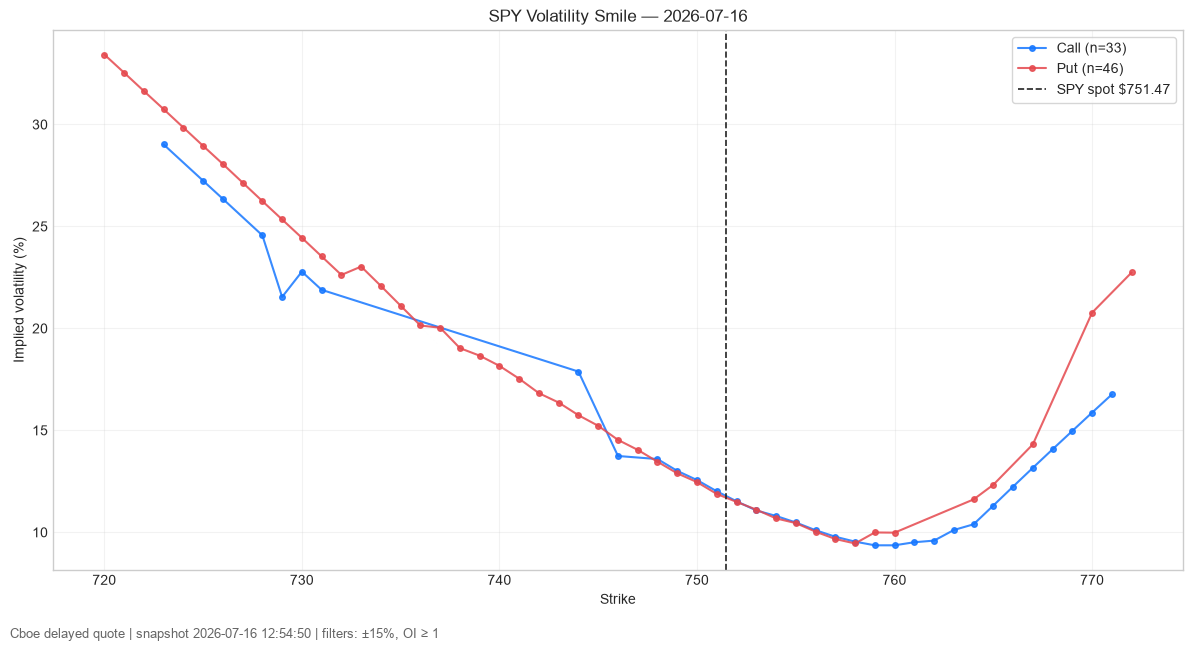

In [5]:
smile = chain.loc[chain["expiration"] == selected_expiration].copy()
smile = smile.loc[
    smile["iv_percent"].between(0.01, 300)
    & smile["strike"].between(spot * (1 - MONEYNESS_WINDOW), spot * (1 + MONEYNESS_WINDOW))
    & (smile["open_interest"].fillna(0) >= MIN_OPEN_INTEREST)
]
if REQUIRE_TWO_SIDED_QUOTE:
    smile = smile.loc[(smile["bid"] > 0) & (smile["ask"] > smile["bid"])]
smile = smile.sort_values(["right", "strike"])

if smile.empty:
    raise RuntimeError("过滤后没有数据。可尝试扩大 MONEYNESS_WINDOW、将 MIN_OPEN_INTEREST 设为 0，或关闭双边报价过滤。")

fig, ax = plt.subplots(figsize=(12, 6.5))
colors = {"Call": "#1677ff", "Put": "#e5484d"}
for right, group in smile.groupby("right", sort=False):
    ax.plot(group["strike"], group["iv_percent"], marker="o", ms=4, lw=1.5,
            alpha=0.85, color=colors[right], label=f"{right} (n={len(group)})")

ax.axvline(spot, color="#222222", ls="--", lw=1.2, label=f"SPY spot ${spot:,.2f}")
ax.set(title=f"SPY Volatility Smile — {selected_expiration:%Y-%m-%d}",
       xlabel="Strike", ylabel="Implied volatility (%)")
ax.legend(frameon=True)
ax.grid(alpha=0.25)
fig.text(0.01, 0.01, f"Cboe delayed quote | snapshot {payload['timestamp']} | filters: ±{MONEYNESS_WINDOW:.0%}, OI ≥ {MIN_OPEN_INTEREST}",
         fontsize=9, color="#666666")
plt.tight_layout(rect=(0, 0.035, 1, 1))
plt.show()

## 图中数据

下面列出绘图所用合约，方便检查异常点。`iv_percent` 是 Cboe 提供的隐含波动率乘以 100，并非本项目自行反解。

In [6]:
display_columns = ["option", "right", "expiration", "strike", "bid", "ask", "iv_percent", "volume", "open_interest", "delta"]
smile[display_columns].reset_index(drop=True).style.format({
    "strike": "{:.2f}", "bid": "{:.2f}", "ask": "{:.2f}",
    "iv_percent": "{:.2f}%", "delta": "{:.3f}"
})

,option,right,expiration,strike,bid,ask,iv_percent,volume,open_interest,delta
0,SPY260716C00723000,Call,2026-07-16 00:00:00,723.00,30.09,32.88,29.02%,2.000000,1.000000,0.996
1,SPY260716C00725000,Call,2026-07-16 00:00:00,725.00,28.09,30.89,27.24%,7.000000,28.000000,0.996
2,SPY260716C00726000,Call,2026-07-16 00:00:00,726.00,27.09,29.89,26.35%,0.000000,2.000000,0.995
3,SPY260716C00728000,Call,2026-07-16 00:00:00,728.00,25.09,27.89,24.56%,0.000000,1.000000,0.995
4,SPY260716C00729000,Call,2026-07-16 00:00:00,729.00,24.09,26.89,21.54%,0.000000,3.000000,0.994
5,SPY260716C00730000,Call,2026-07-16 00:00:00,730.00,23.09,25.88,22.78%,2.000000,51.000000,0.994
6,SPY260716C00731000,Call,2026-07-16 00:00:00,731.00,22.09,24.88,21.89%,50.000000,57.000000,0.993
7,SPY260716C00744000,Call,2026-07-16 00:00:00,744.00,9.77,11.64,17.88%,119.000000,51.000000,0.955
8,SPY260716C00746000,Call,2026-07-16 00:00:00,746.00,8.36,8.90,13.74%,265.000000,85.000000,0.930
9,SPY260716C00748000,Call,2026-07-16 00:00:00,748.00,6.72,6.81,13.59%,1217.000000,457.000000,0.888
